# without SMOTEN with k-fold

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
# بارگذاری داده‌ها
data = pd.read_csv('/content/Churn_Modelling.csv')

# بررسی داده‌ها
print(data.head())

# جدا کردن ویژگی‌ها و هدف
X = data.drop(['Exited'], axis=1)  # فرض بر این است که 'Exited' نام ستون هدف است
y = data['Exited']

# پیش‌پردازش داده‌ها
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

# ساخت یک پیش‌پردازشور
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [ ]:

# تقسیم داده‌ها به مجموعه‌های آموزشی و آزمایشی
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# پیش‌پردازش داده‌ها
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# تعریف KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# تعریف یک تابع برای آموزش و ارزیابی مدل
def evaluate_model(X, y):
    # ساخت مدل DNN
    model = keras.Sequential([
        layers.Dense(10, activation='relu', input_shape=(X.shape[1],)),
        layers.Dense(6, activation='relu'),
        layers.Dense(6, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # خروجی باینری
    ])

    # کامپایل مدل
    model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])

    # آموزش مدل
    model.fit(X, y, epochs=50, batch_size=32, verbose=0)  # verbose=0 برای خاموش کردن چاپ
    return model

# لیست برای ذخیره نتایج
accuracies = []

# اعتبارسنجی متقاطع
for train_index, test_index in kf.split(X_train):
    X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    model = evaluate_model(X_train_fold, y_train_fold)
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    accuracies.append(accuracy)

# محاسبه میانگین دقت
mean_accuracy = np.mean(accuracies)
print(f'Mean Accuracy from 10-Fold Cross-Validation: {mean_accuracy * 100:.2f}%')

# ارزیابی نهایی مدل روی مجموعه آزمایشی
final_model = evaluate_model(X_train, y_train)
loss, accuracy = final_model.evaluate(X_test, y_test)
print(f'Final Model Accuracy on Test Set: {accuracy * 100:.2f}%')


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mean Accuracy from 10-Fold Cross-Validation: 84.73%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8443 - loss: 0.3582
Final Model Accuracy on Test Set: 85.10%


In [45]:

# پیش‌بینی
predictions = final_model.predict(X_test)
predictions = (predictions > 0.5).astype(int)  # آستانه 0.5 برای پیش‌بینی

# محاسبه دقت و یادآوری
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)

# نمایش نتایج
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

# محاسبه ماتریس سردرگمی
conf_matrix = confusion_matrix(y_test, predictions)
print('Confusion Matrix:')
print(conf_matrix)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Precision: 0.68
Recall: 0.46
Confusion Matrix:
[[1521   86]
 [ 212  181]]


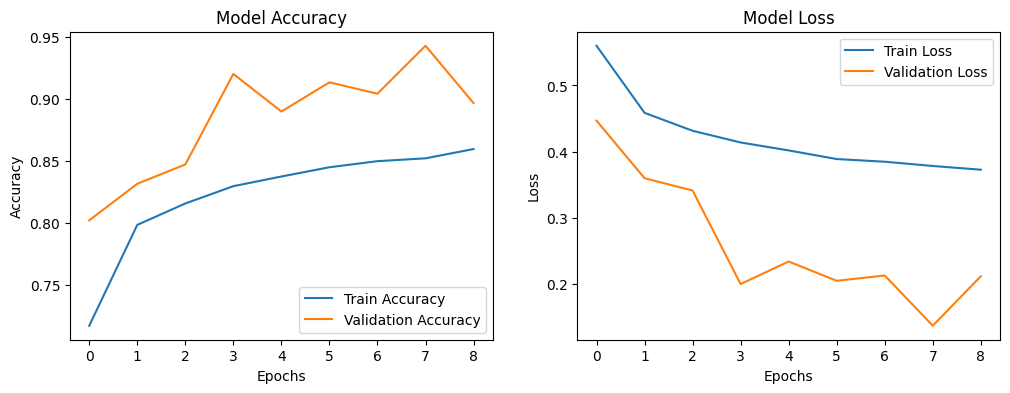

In [46]:

# Plotting history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

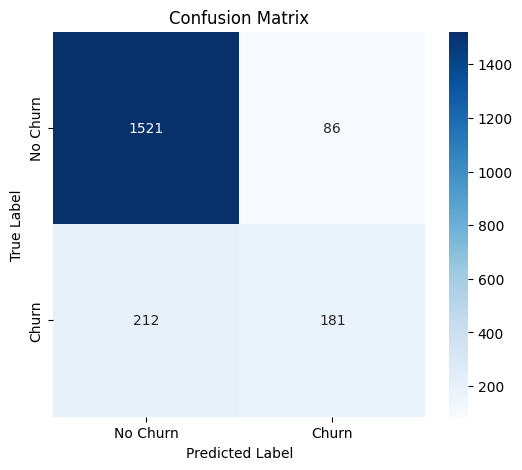

In [47]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

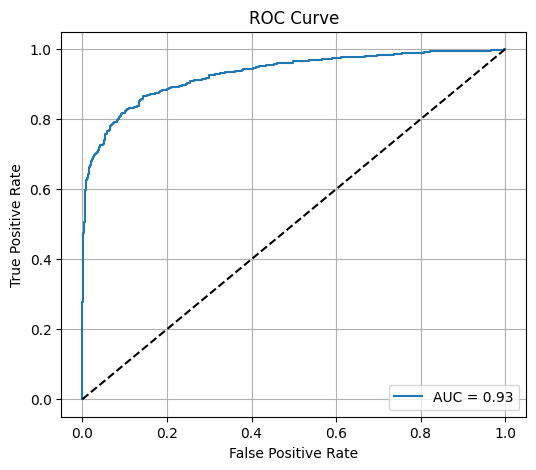

In [48]:
from sklearn.metrics import roc_curve

# محاسبه مقادیر برای رسم منحنی ROC
fpr, tpr, thresholds = roc_curve(Y_smot_test, y_pred)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # خط مرجع
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
